
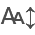

In [1]:
import pandas as pd
import os
import numpy as np
from copy import deepcopy

import plotly.graph_objects as go
from plotly.subplots import make_subplots
import plotly.io as pio

import seaborn as sns
import matplotlib.pyplot as plt

from scipy.stats import fisher_exact
from scipy.stats import chi2_contingency
from scipy.stats import mannwhitneyu
from scipy.stats import pointbiserialr
from statsmodels.stats.outliers_influence import variance_inflation_factor

from itables import init_notebook_mode
init_notebook_mode(all_interactive=True)


In [2]:
processed_data_input_path = os.path.join(os.getcwd(), '..', 'data', 'data_processed')
figures_path = os.path.join(os.getcwd(), '..', 'data', 'visualizations')

In [3]:
df = pd.read_csv(os.path.join(processed_data_input_path, 'features_added.csv'))
df.set_index('Unnamed: 0', inplace=True)
df.index.name = None
df

Loading ITables v2.4.0 from the init_notebook_mode cell... (need help?)


**Analiza danych pogodowych**

*Sprawdzenie czy poszczególne warunki pogodowe mają wpływ na występowanie niespodzianek*

In [4]:
# df['is_cold'] = (df['temperature_2m'] < 5).astype(int)
# df['is_very_cold'] = (df['temperature_2m'] < 0).astype(int)
# df['is_warm'] = (df['temperature_2m'] > 25).astype(int)
# df['is_rainy'] = (df['rain'] > 1.0).astype(int)
# df['is_snowy'] = (df['snowfall'] > 0).astype(int)
# df['is_humid'] = (df['relative_humidity_2m'] > 85).astype(int)
# df['is_dry_air'] = (df['relative_humidity_2m'] < 40).astype(int)
# df['is_windy'] = (df['wind_speed_10m'] > 25).astype(int)
# df['is_very_windy'] = (df['wind_speed_10m'] > 35).astype(int)
# df['is_gusty'] = (df['wind_gusts_10m'] > 30).astype(int)
# df['is_low_pressure'] = (df['surface_pressure'] < 1000).astype(int)
# df['is_cloudy'] = (df['cloud_cover'] > 80).astype(int)

# columns based on percentiles
p = df[[
    'temperature_2m',
    'rain',
    'snowfall',
    'relative_humidity_2m',
    'wind_speed_10m',
    'wind_gusts_10m',
    'surface_pressure',
    'cloud_cover'
]].quantile([0.1, 0.9, 0.97, 0.95])

# Define thresholds for weather conditions
thresholds = {
    'is_cold': p.loc[0.1, 'temperature_2m'],
    'is_freezing': 0,  
    'is_warm': p.loc[0.9, 'temperature_2m'],
    'is_rainy': p.loc[0.9, 'rain'],
    'is_heavy_rain': p.loc[0.97, 'rain'],  
    'is_snowy': 0,
    'is_humid': p.loc[0.9, 'relative_humidity_2m'],
    'is_dry_air': p.loc[0.1, 'relative_humidity_2m'],
    'is_windy': p.loc[0.9, 'wind_speed_10m'],
    'is_very_windy': p.loc[0.97, 'wind_speed_10m'],
    'is_gusty': p.loc[0.9, 'wind_gusts_10m'],
    'is_low_pressure': p.loc[0.1, 'surface_pressure'],
    'is_cloudy': 99
}
# Use percentiles instead of fixed thresholds
df['is_cold'] = (df['temperature_2m'] < thresholds['is_cold']).astype(int)
df['is_freezing'] = (df['temperature_2m'] < thresholds['is_freezing']).astype(int)  # optionally adjust

df['is_warm'] = (df['temperature_2m'] > thresholds['is_warm']).astype(int)

df['is_rainy'] = (df['rain'] > thresholds['is_rainy']).astype(int)
df['is_heavy_rain'] = (df['rain'] > thresholds['is_heavy_rain']).astype(int)  # optional offset

df['is_snowy'] = (df['snowfall'] > thresholds['is_snowy']).astype(int)

df['is_humid'] = (df['relative_humidity_2m'] > thresholds['is_humid']).astype(int)
df['is_dry_air'] = (df['relative_humidity_2m'] < thresholds['is_dry_air']).astype(int)

df['is_windy'] = (df['wind_speed_10m'] > thresholds['is_windy']).astype(int)
df['is_very_windy'] = (df['wind_speed_10m'] > thresholds['is_very_windy']).astype(int)  # optional

df['is_gusty'] = (df['wind_gusts_10m'] > thresholds['is_gusty']).astype(int)

df['is_low_pressure'] = (df['surface_pressure'] < thresholds['is_low_pressure']).astype(int)

df['is_cloudy'] = (df['cloud_cover'] > thresholds['is_cloudy']).astype(int)


In [5]:
# to analyze weather dependency, only game hosts row can be selected
dfw = df[df['home_game'] == 1].copy()
dfw

Loading ITables v2.4.0 from the init_notebook_mode cell... (need help?)


In [6]:

unexp_res_percent = pd.DataFrame(columns=['weather_condition', 'count', 'threshold', 'percent_of_occurance', 'procent zaskoczeń w całym zbiorze', 'procent zaskoczeń w podzbiorze', 'procentowa zmiana względna'])
# unexp_res_percent.loc[0] = ['all', dfw.shape[0], 100, dfw[dfw['prob_unexpected_result'] == 1].shape[0] / dfw.shape[0] * 100, None]
for col, thr in thresholds.items():
    unexp_res_percent.loc[len(unexp_res_percent)] = [
        col,
        dfw[dfw[col] == 1].shape[0],
        thr,
        dfw[dfw[col] == 1].shape[0] / dfw.shape[0] * 100,
        0 if dfw[dfw[col] == 1].shape[0] == 0 else dfw[dfw['prob_unexpected_result'] == 1].shape[0] / dfw.shape[0] * 100,
        0 if dfw[dfw[col] == 1].shape[0] == 0 else dfw[(dfw[col] == 1) & (dfw['prob_unexpected_result'] == 1)].shape[0] / dfw[dfw[col] == 1].shape[0] * 100,
        0 if dfw[dfw[col] == 1].shape[0] == 0 
            else ((dfw[(dfw[col] == 1) & (dfw['prob_unexpected_result'] == 1)].shape[0] / dfw[dfw[col] == 1].shape[0] * 100) / (dfw[dfw['prob_unexpected_result'] == 1].shape[0] / dfw.shape[0] * 100) - 1) * 100
    ]
    
unexp_res_percent.round(2).sort_values(by='procent zaskoczeń w podzbiorze', ascending=False).reset_index(drop=True)

Loading ITables v2.4.0 from the init_notebook_mode cell... (need help?)


*Sprawdzenie czy połączenie dwóch niekorzystnych warunków pogodowych zwiększa szansę na wystąpienie niespodzianek*

In [7]:
unexp_res_percent_2 = pd.DataFrame(columns=['weather_condition1', 'weather_condition2', 'count', 'percent_of_occurance', 'procent zaskoczeń w całym zbiorze', 'procent zaskoczeń w podzbiorze', 'procentowa zmiana względna'])
# unexp_res_percent_2.loc[0] = ['all', 'all', dfw.shape[0], 100, dfw[dfw['prob_unexpected_result'] == 1].shape[0] / dfw.shape[0] * 100]
for col1 in thresholds.keys():
    for col2 in thresholds.keys():
        cond = (dfw[col1] == 1) & (dfw[col2] == 1)
        if col1 == col2 or not cond.any():
            continue
        if unexp_res_percent_2.loc[(unexp_res_percent_2['weather_condition1'] == col2) & (unexp_res_percent_2['weather_condition2'] == col1)].shape[0] == 1:
            continue
        unexp_res_percent_2.loc[len(unexp_res_percent_2)] = [
            col1,
            col2,
            dfw[cond].shape[0],
            dfw[cond].shape[0] / dfw.shape[0] * 100,
            0 if dfw[cond].shape[0] == 0 else dfw[dfw['prob_unexpected_result'] == 1].shape[0] / dfw.shape[0] * 100,
            0 if dfw[cond].shape[0] == 0 
                else dfw[cond & (dfw['prob_unexpected_result'] == 1)].shape[0] / dfw[cond].shape[0] * 100,
            0 if dfw[cond].shape[0] == 0 
                else ((dfw[cond & (dfw['prob_unexpected_result'] == 1)].shape[0] / dfw[cond].shape[0] * 100) / (dfw[dfw['prob_unexpected_result'] == 1].shape[0] / dfw.shape[0] * 100) - 1) * 100
        ]
    
unexp_res_percent_2[unexp_res_percent_2['percent_of_occurance'] > 1].round(2).sort_values(by='procent zaskoczeń w podzbiorze', ascending=False).reset_index(drop=True)

Loading ITables v2.4.0 from the init_notebook_mode cell... (need help?)


In [8]:
dfw['is_humid_or_warm_and_is_cloudy'] = (((dfw['is_humid'] == 1) | (dfw['is_warm'] == 1)) & (dfw['is_cloudy'] == 1)).astype(int)
dfw['is_humid_is_cloudy'] = ((dfw['is_humid'] == 1) & (dfw['is_cloudy'] == 1)).astype(int)

weather_cols = list(thresholds.keys()) + ['is_humid_or_warm_and_is_cloudy', 'is_humid_is_cloudy']

*Test χ² (chi-kwadrat niezależności) - sprawdzanie czy dwie zmienne kategoryczne (np. binarne) są od siebie statystycznie zależne.*

In [9]:
def chi2_test_var_vs_target(dfw, binary_var, target='prob_unexpected_result'):
    table = pd.crosstab(dfw[binary_var], dfw[target])

    chi2, p, dof, expected = chi2_contingency(table)
    return {
        'variable': binary_var,
        'p_value': p,
        'chi2_stat': chi2,
        'degrees_of_freedom_chi': dof
    }


chi2_test = [chi2_test_var_vs_target(dfw, col) for col in weather_cols]
chi2_dfw = pd.DataFrame(chi2_test).sort_values(by='p_value')
chi2_dfw

Loading ITables v2.4.0 from the init_notebook_mode cell... (need help?)


Test Fishera - alternatywa dla χ² (chi-kwadrat niezależności), dobra dla mniejszych próbek i niskiej reprezentatywności

In [10]:
def fisher_test_var_vs_target(dfw, binary_var, target='prob_unexpected_result'):
    # Tworzymy tabelę kontyngencji
    table = pd.crosstab(dfw[binary_var], dfw[target])
    
    # Sprawdzamy, czy mamy dokładnie tabelę 2x2
    if table.shape != (2, 2):
        return {
            'variable': binary_var,
            'error': 'Fisher’s exact test is only valid for 2x2 tables',
            'p_value_fisher': None,
            'odds_ratio_fisher': None
        }
    
    # Konwertujemy na listę list i wykonujemy test
    odds_ratio, p_value = fisher_exact(table)
    
    return {
        'variable': binary_var,
        'p_value': p_value,
        'odds_ratio': odds_ratio
    }

fisher_test = [fisher_test_var_vs_target(dfw, col) for col in weather_cols]
fisher_dfw = pd.DataFrame(fisher_test).sort_values(by='p_value')
fisher_dfw



Loading ITables v2.4.0 from the init_notebook_mode cell... (need help?)


In [11]:
dfw[dfw['is_humid_is_cloudy'] == 1]

Loading ITables v2.4.0 from the init_notebook_mode cell... (need help?)


Dodanie kolumn wykazujących zależność do zbioru danych

In [12]:
df['is_humid_or_warm_and_is_cloudy'] = (((df['is_humid'] == 1) | df['is_warm'] == 1) & (df['is_cloudy'] == 1)).astype(int)
df['is_humid_is_cloudy'] = ((df['is_humid'] == 1) & (df['is_cloudy'] == 1)).astype(int)

In [13]:
df

Loading ITables v2.4.0 from the init_notebook_mode cell... (need help?)


**EDA**

In [14]:
for col in df.columns:
    print(col)

season
gameweek
dayofweek
datetime
team
opponent
home_game
xG
xGA
possesion
possesion_against
passes_accuracy
passes_accuracy_against
passes_total
passes_completed
passes_total_against
passes_completed_against
crosses
crosses_against
touches
touches_against
idx
comp_before
comp_before_name
comp_before_date
comp_after
comp_after_name
comp_after_date
manager
referee
goals_scored
goals_conceded
result
goals_scored_h1
goals_conceded_h1
result_h1
shots
shots_against
shots_on_target
shots_on_target_against
corners
corners_against
fouls
fouls_against
yellow_cards
yellow_cards_against
red_cards
red_cards_against
win_odds
draw_odds
loss_odds
over_2_5_goals_odds
under_2_5_goals_odds
datetime_weather
temperature_2m
apparent_temperature
precipitation
rain
snowfall
surface_pressure
wind_speed_10m
relative_humidity_2m
wind_gusts_10m
cloud_cover
et0_fao_evapotranspiration
stadium_team
stadium
latitude
longitude
xG_difference
goals_difference
shots_difference
shots_on_target_difference
possesion_diffe

Czy zmienne rolling mogą być zbliżone do rozkładu normalnego?

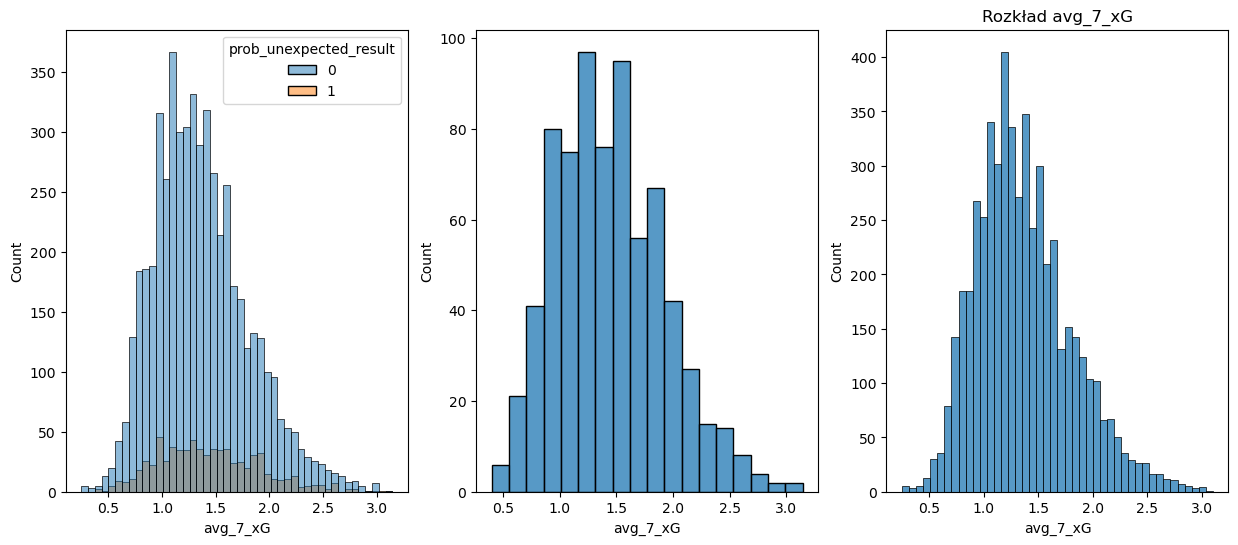

In [15]:
import seaborn as sns
import matplotlib.pyplot as plt
fig, ax = plt.subplots(1,3, figsize=(15, 6))
sns.histplot(df, x='avg_7_xG', hue='prob_unexpected_result', ax=ax[0])
sns.histplot(df[df['prob_unexpected_result'] == 1], x='avg_7_xG', ax=ax[1])
sns.histplot(df[df['prob_unexpected_result'] == 0], x='avg_7_xG', ax=ax[2])
plt.title("Rozkład avg_7_xG")
plt.show()

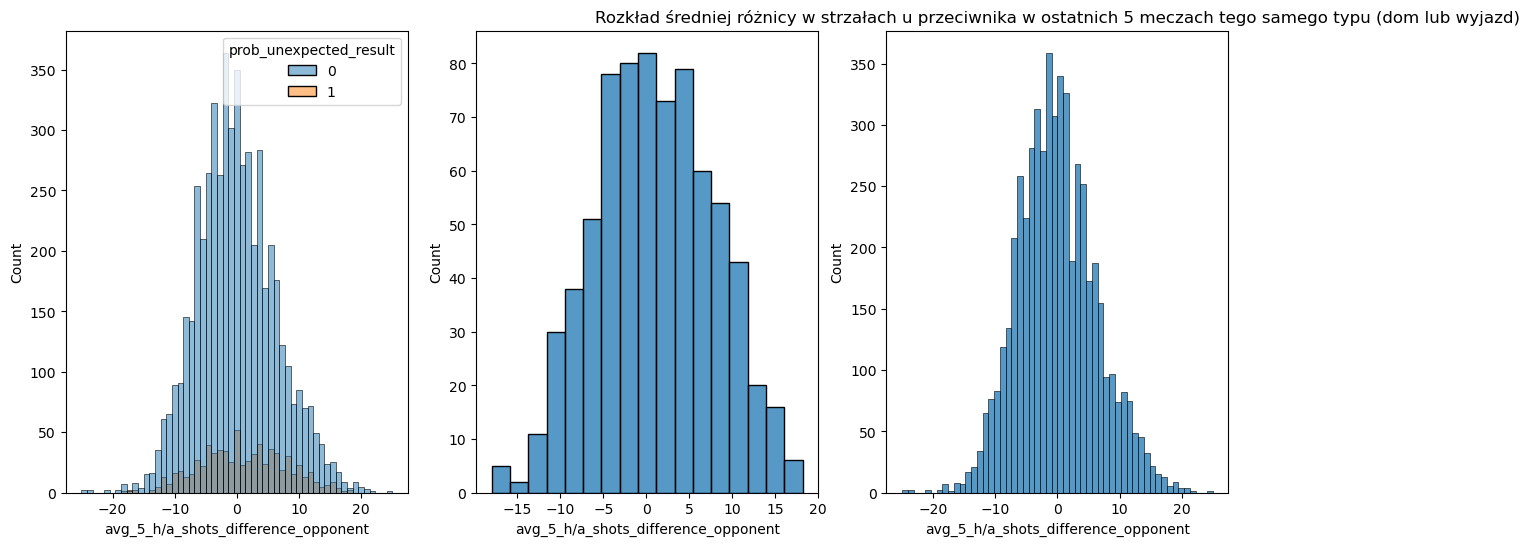

In [16]:
import seaborn as sns
import matplotlib.pyplot as plt
fig, ax = plt.subplots(1,3, figsize=(15, 6))
sns.histplot(df, x='avg_5_h/a_shots_difference_opponent', hue='prob_unexpected_result', ax=ax[0])
sns.histplot(df[df['prob_unexpected_result'] == 1], x='avg_5_h/a_shots_difference_opponent', ax=ax[1])
sns.histplot(df[df['prob_unexpected_result'] == 0], x='avg_5_h/a_shots_difference_opponent', ax=ax[2])
plt.title("Rozkład średniej różnicy w strzałach u przeciwnika w ostatnich 5 meczach tego samego typu (dom lub wyjazd)")
plt.show()

In [17]:
suffixes = [
'avg_7_',
'avg_3_',
'last_1_',
'avg_5_h/a_']

cols = ['xG_difference',
'shots_difference',
'shots_on_target_difference',
'passes_completed_difference',
'passes_total_difference',
'crosses_difference',
'touches_difference',
'possesion_difference',
'goals_difference',
'corners_difference',
'points']

cont_cols = [f"{suffix}{col}" for suffix in suffixes for col in cols]
cont_cols= cont_cols + [f"{col}_opponent" for col in cont_cols]
cont_cols += [
    'season_points',
    'season_goals_scored',
    'season_goals_conceded',
    'season_goals_difference',
    'league_position',
    'elo',
    'season_points_opponent',
    'season_goals_scored_opponent',
    'season_goals_conceded_opponent',
    'season_goals_difference_opponent',
    'league_position_opponent',
    'elo_opponent',
    'elo_diff',
    'temperature_2m',
    'apparent_temperature',
    'precipitation',
    'rain',
    'snowfall',
    'surface_pressure',
    'wind_speed_10m',
    'relative_humidity_2m',
    'wind_gusts_10m',
    'cloud_cover',
    'et0_fao_evapotranspiration',
    'days_of_rest',
    'days_of_rest_opponent',
]
len(cont_cols)

114

In [18]:
df[cont_cols].isna().sum().sort_values(ascending=False)

Loading ITables v2.4.0 from the init_notebook_mode cell... (need help?)


Test U Manna-Whitneya sprawdzający czy cecha jest istotnie różna dla meczów będących niespodzianką

In [19]:
def mann_whitney_test(df, variable, target='prob_unexpected_result'):
    group1 = df[df[target] == 1][variable]
    group2 = df[df[target] == 0][variable]
    
    if group1.empty or group2.empty:
        return [variable, None, None]
    
    u_statistic, p_value = mannwhitneyu(group1, group2, alternative='two-sided', nan_policy='omit')
    
    return [variable, p_value, u_statistic]
    
umannwhittney_df = pd.DataFrame(columns=['variable', 'p_value_mannwhit', 'u_statistic'])


for col in cont_cols:
    result = mann_whitney_test(df, col)
    umannwhittney_df.loc[len(umannwhittney_df)] = result
    
umannwhittney_df = umannwhittney_df.sort_values(by='p_value_mannwhit', ascending=False).reset_index(drop=True)
# umannwhittney_df['p_value_form'] = umannwhittney_df['p_value'].apply(lambda x: f"{x:.10f}")
umannwhittney_df


Loading ITables v2.4.0 from the init_notebook_mode cell... (need help?)


Wskaźnik siły zależności: punktowo-biseryjna korelacja Pearsona

In [20]:
def pointbiserial_corr(df, variable, target='prob_unexpected_result'):
    group1 = df.loc[df[variable].notna() & df[target].notna(), variable]
    group2 = df.loc[df[variable].notna() & df[target].notna(), target]
    r, p_value = pointbiserialr(group1, group2)

    return [variable, p_value, r]
    
pointbiserial_corr_df = pd.DataFrame(columns=['variable', 'p_value_corr', 'r'])

for col in cont_cols:
    result = pointbiserial_corr(df, col)
    pointbiserial_corr_df.loc[len(pointbiserial_corr_df)] = result
    
pointbiserial_corr_df = pointbiserial_corr_df .sort_values(by='p_value_corr', ascending=False).reset_index(drop=True)
# pointbiserial_corr_df ['p_value_form'] = pointbiserial_corr_df ['p_value'].apply(lambda x: f"{x:.10f}")
pointbiserial_corr_df

Loading ITables v2.4.0 from the init_notebook_mode cell... (need help?)


Filtracja zmiennych o nieistotnej statystycznie zależności z targetem 

In [21]:
df_stats = pd.merge(
    umannwhittney_df,
    pointbiserial_corr_df,
    on='variable',
    how='inner'
)
df_stats['r_abs'] = df_stats['r'].abs()
df_stats = df_stats[(df_stats['p_value_mannwhit'] < 0.05) & ((df_stats['p_value_corr'] < 0.05))].sort_values(by='r_abs', ascending=False).reset_index(drop=True)

df_stats

Loading ITables v2.4.0 from the init_notebook_mode cell... (need help?)


In [22]:
df_statsw = pd.merge(
    umannwhittney_df,
    pointbiserial_corr_df,
    on='variable',
    how='inner'
)
df_statsw['r_abs'] = df_stats['r'].abs()
df_statsw.loc[df_statsw['variable'].isin(["temperature_2m", "apparent_temperature", "precipitation", "rain", "snowfall", "surface_pressure", 
             "wind_speed_10m", "relative_humidity_2m", "wind_gusts_10m", "cloud_cover", "et0_fao_evapotranspiration"])
].sort_index(ascending=False)


Loading ITables v2.4.0 from the init_notebook_mode cell... (need help?)


In [23]:
useable_cols = df_stats['variable'].tolist()
len(useable_cols)

98

Sprawdzenie korelacji między wstępnie przefiltrowanymi zmiennymi ciągłymi i usunięcie tych mających wysoką korelację

68


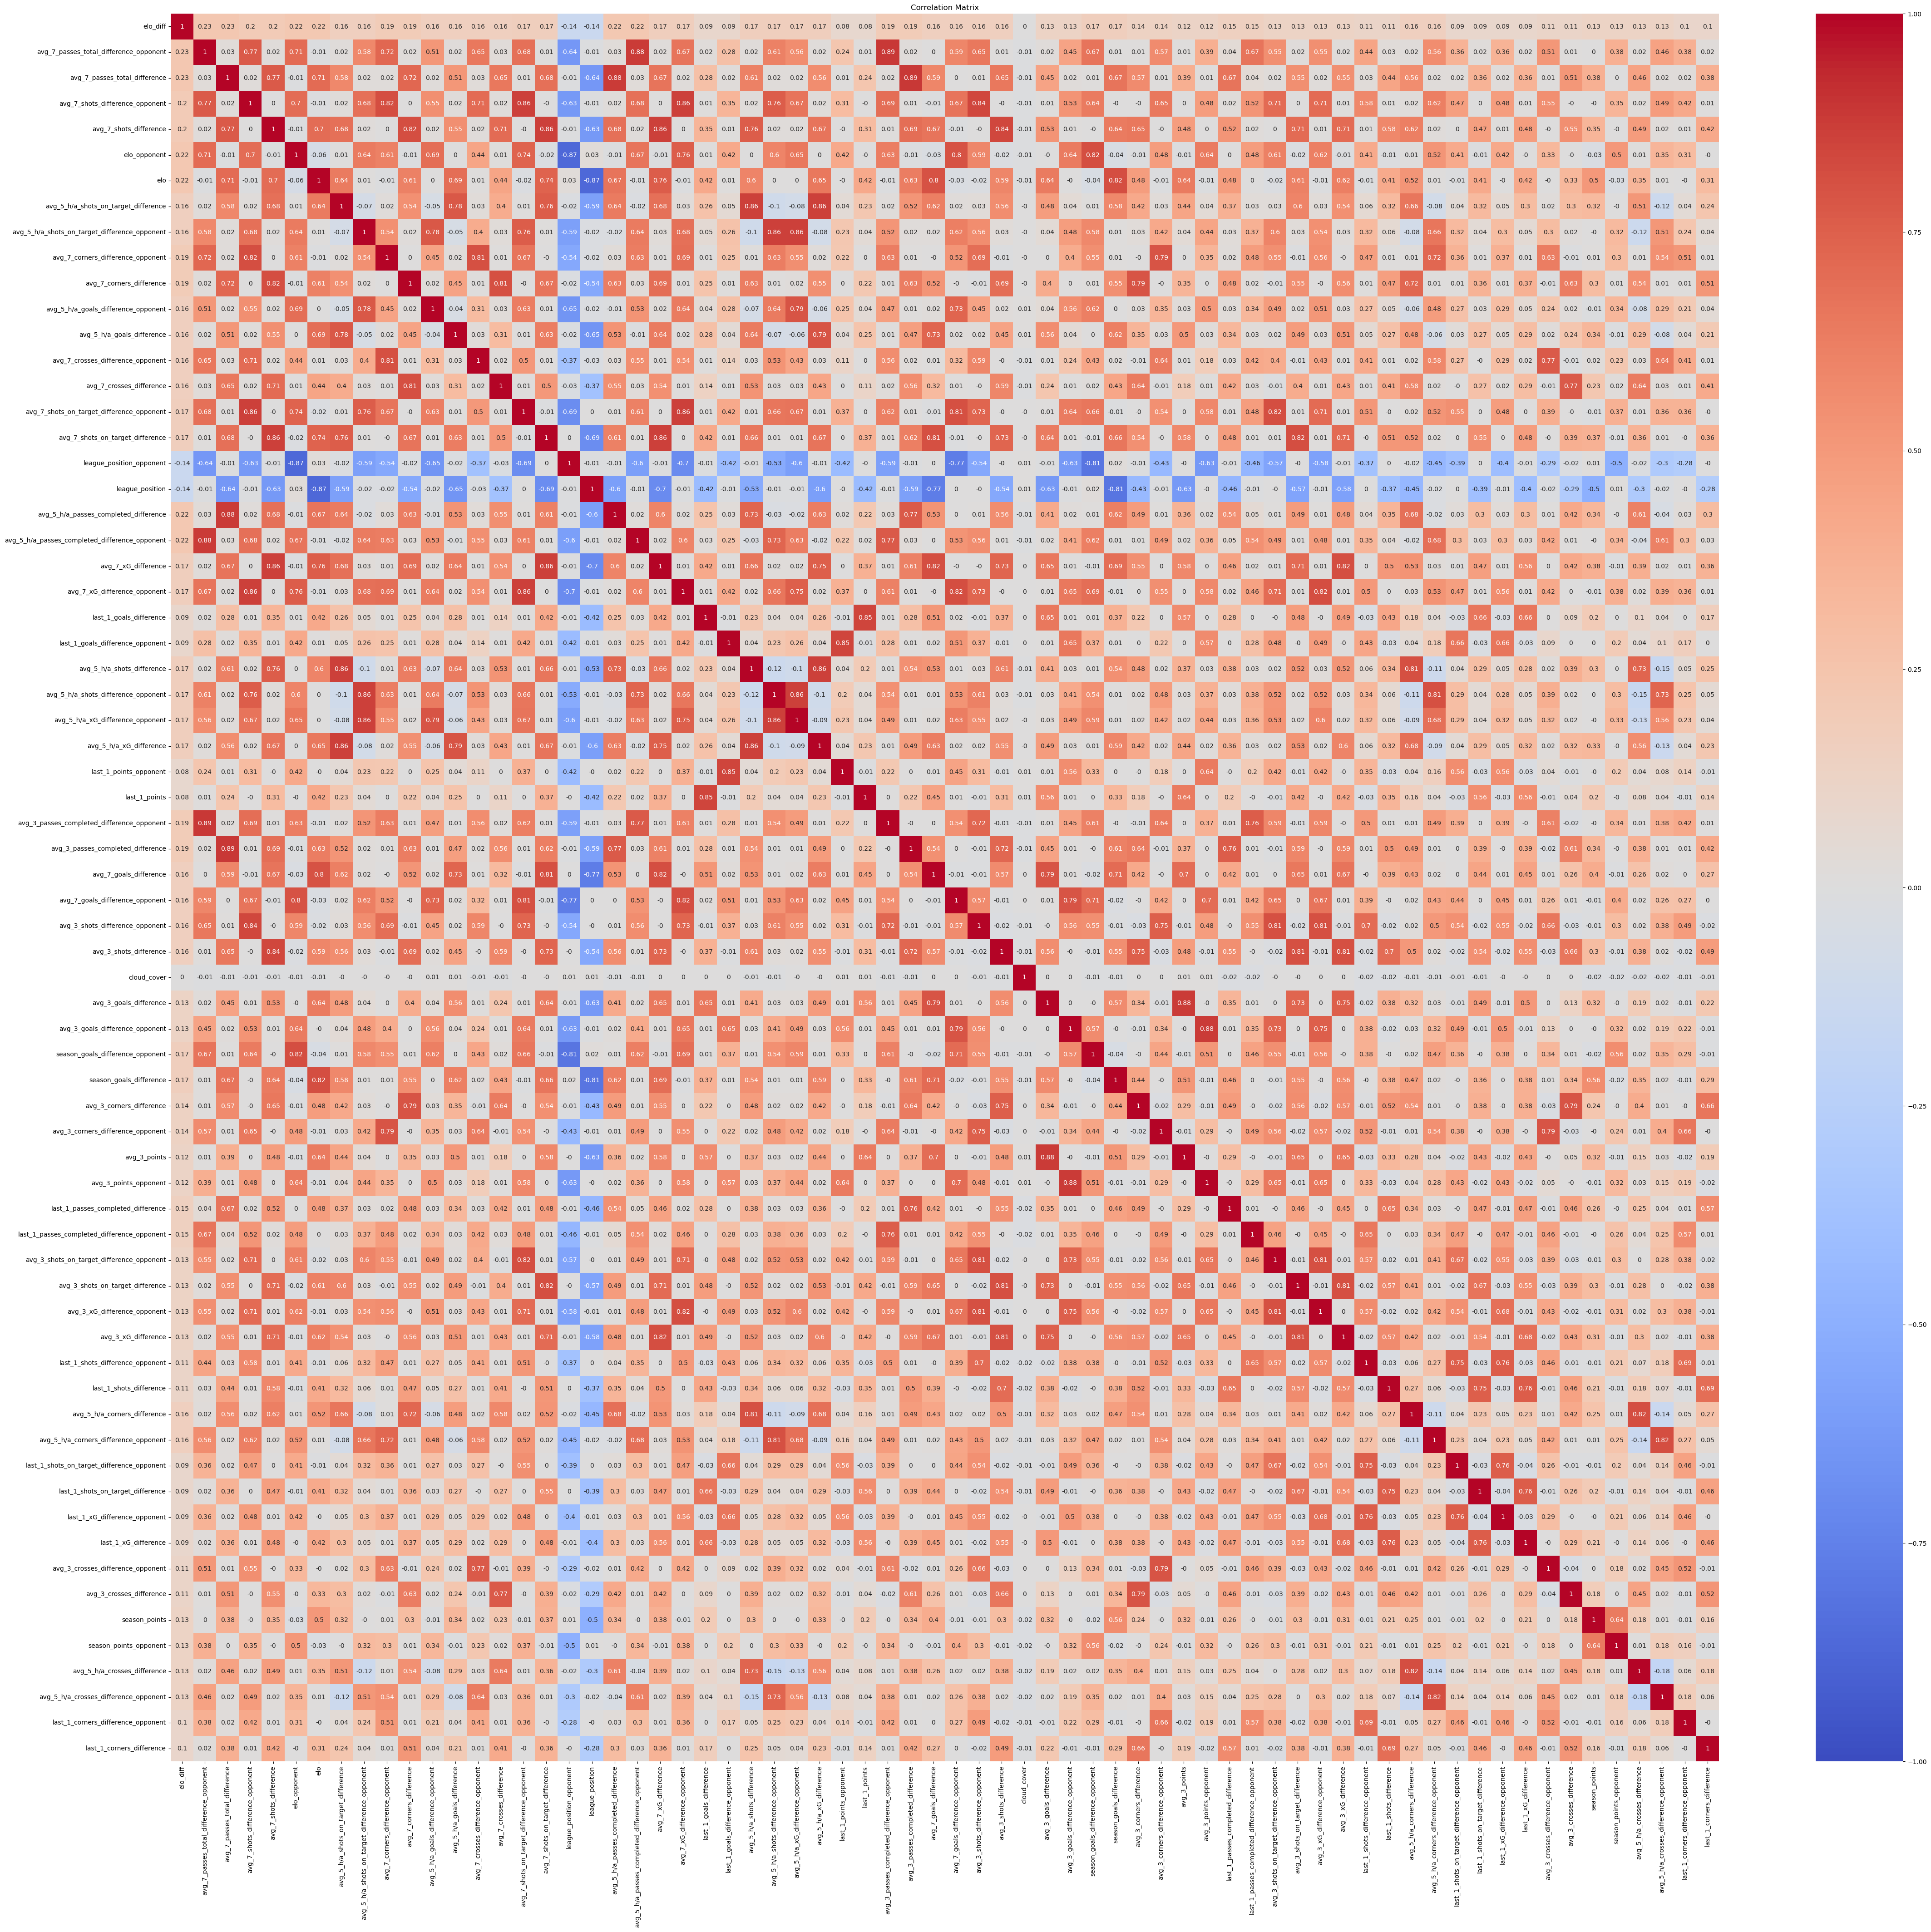

In [24]:
cols_to_drop_based_on_corr = [
    'avg_7_passes_completed_difference_opponent',
    'avg_7_touches_difference_opponent',
    'avg_7_possesion_difference_opponent',
    'avg_7_passes_completed_difference',
    'avg_7_touches_difference',
    'avg_7_possesion_difference',
    'avg_5_h/a_points_opponent',
    'avg_5_h/a_points',
    'avg_5_h/a_touches_difference',
    'avg_5_h/a_passes_total_difference',
    'avg_5_h/a_possesion_difference',
    'avg_5_h/a_touches_difference_opponent',
    'avg_5_h/a_passes_total_difference_opponent',
    'avg_5_h/a_possesion_difference_opponent',
    'avg_3_touches_difference',
    'avg_3_passes_total_difference',
    'avg_3_possesion_difference',
    'avg_3_touches_difference_opponent',
    'avg_3_passes_total_difference_opponent',
    'avg_3_possesion_difference_opponent',
    'avg_7_points_opponent',
    'avg_7_points',
    'last_1_touches_difference',
    'last_1_passes_total_difference',
    'last_1_possesion_difference',
    'last_1_touches_difference_opponent',
    'last_1_passes_total_difference_opponent',
    'last_1_possesion_difference_opponent',
    'season_goals_scored',
    'season_goals_scored_opponent',
]
useable_cols = [col for col in useable_cols if col not in cols_to_drop_based_on_corr]
print(len(useable_cols))
corr = df[useable_cols].corr().round(2)

# Plot heatmap
plt.figure(figsize=(55, 50))
sns.heatmap(corr, annot=True, cmap='coolwarm', vmin=-1, vmax=1)
plt.title('Correlation Matrix')
plt.savefig(os.path.join(figures_path, 'correlation_matrix_continous_features.png'))
plt.show()


Sprawdzenie kolinearności zmiennych ciągłych

In [25]:
X = df[useable_cols]  # tylko numeryczne kolumny
X = X.dropna()
vif_data = pd.DataFrame({
    'feature': X.columns,
    'VIF': [variance_inflation_factor(X.values, i) for i in range(X.shape[1])]
})
vif_data

Loading ITables v2.4.0 from the init_notebook_mode cell... (need help?)


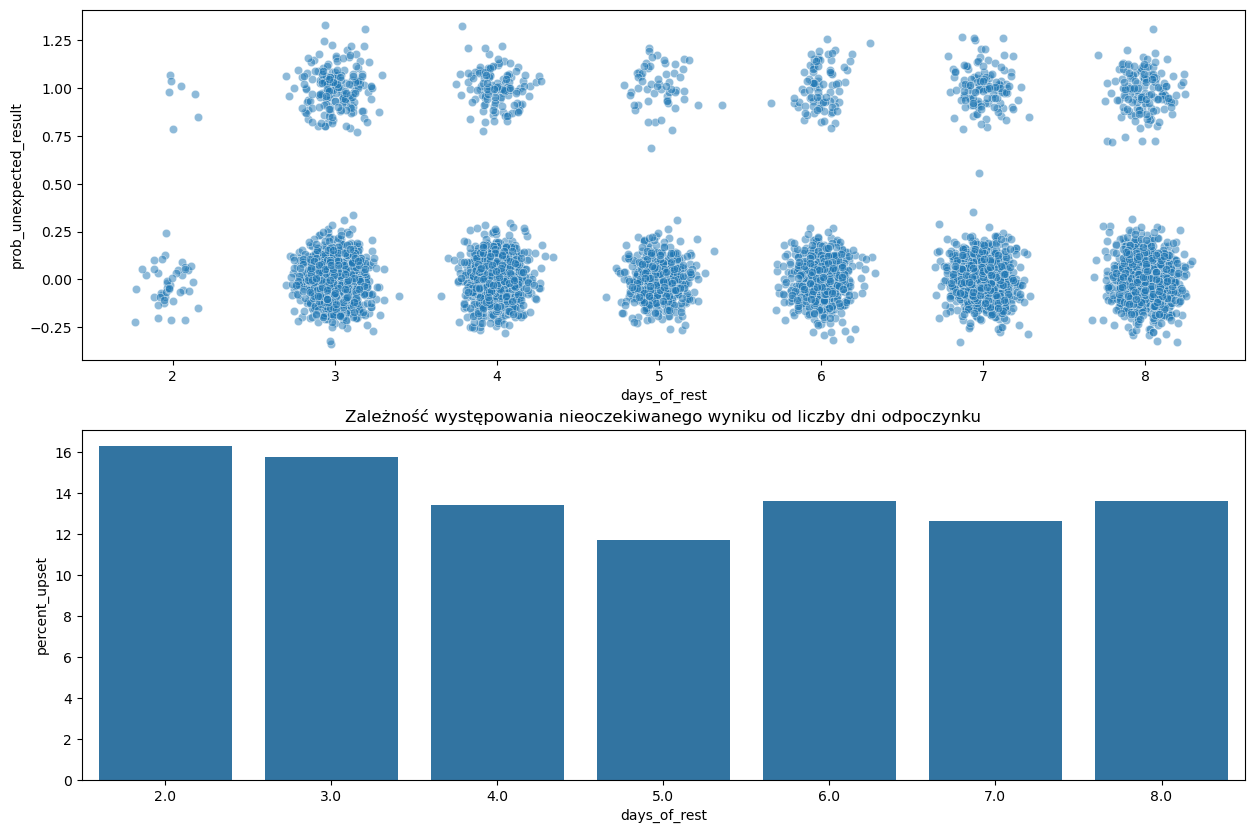

In [26]:
percent_upset_vs_rest = pd.merge(
    df.loc[df['prob_unexpected_result'] == 0, ['days_of_rest', 'prob_unexpected_result']].groupby('days_of_rest').count(),
    df.loc[df['prob_unexpected_result'] == 1, ['days_of_rest', 'prob_unexpected_result']].groupby('days_of_rest').count(),
    on='days_of_rest'
)
percent_upset_vs_rest['percent_upset'] = (percent_upset_vs_rest['prob_unexpected_result_y'] / percent_upset_vs_rest['prob_unexpected_result_x']) * 100 
percent_upset_vs_rest['percent_upset']

fig, ax = plt.subplots(2,1, figsize=(15, 10))
sns.scatterplot(x=df['days_of_rest'] + np.random.normal(0, 0.1, size=len(df)), y=df['prob_unexpected_result']+ np.random.normal(0, 0.1, size=len(df)), ax=ax[0], alpha=0.5)
sns.barplot(x=percent_upset_vs_rest.index, y=percent_upset_vs_rest['percent_upset'], ax=ax[1])

plt.title("Zależność występowania nieoczekiwanego wyniku od liczby dni odpoczynku")
plt.show()

In [27]:
df['short_rest'] = (df['days_of_rest'] < 5).astype(int)
df['comp_before_or_after'] = ((df['comp_before'] == 1) | (df['comp_after'] == 1)).astype(int)
df['comp_before_and_after'] = ((df['comp_before'] == 1) & (df['comp_after'] == 1)).astype(int)
df['comp_before_and_short_rest'] = ((df['comp_before'] == 1) & (df['short_rest'] == 1)).astype(int)

Test zależności zmiennych binarnych - testy χ² oraz Fishera

In [28]:
binary_cols = ['home_game',
    'comp_before',
    'comp_after',
    'is_new_manager',
    'is_new_manager_opponent',
    'short_rest',
    'comp_before_and_after',
    'comp_before_or_after',
    'comp_before_and_short_rest'
]

In [29]:
chi2_test = [chi2_test_var_vs_target(df, col) for col in binary_cols]
chi2_df = pd.DataFrame(chi2_test).sort_values(by='p_value')
chi2_df

Loading ITables v2.4.0 from the init_notebook_mode cell... (need help?)


In [30]:
fisher_test = [fisher_test_var_vs_target(df, col) for col in binary_cols]
fisher_df = pd.DataFrame(fisher_test).sort_values(by='p_value')
fisher_df


Loading ITables v2.4.0 from the init_notebook_mode cell... (need help?)


Dodanie kolumn binarnych wykazujących zależność ze zmienną objaśnianą do wstępnego zbioru kolumn 

In [31]:
initial_cols_list = useable_cols + ['comp_before_and_short_rest', 'is_humid_or_warm_and_is_cloudy', 'is_humid_is_cloudy', 'prob_unexpected_result']
benchmark_cols = [
    'season',
    'gameweek',
    'team',
    'opponent',
    'home_game',
    'goals_scored',
    'goals_conceded',
    'elo_unexpected_result',
    'win_probability',
    'draw_probability',
    'not_loss_probability',
    'win_odds',
    'draw_odds',
    'loss_odds'
]
initial_cols_list = initial_cols_list + benchmark_cols

Wartości brakujące

In [32]:
# removal of NaN values before training
np.round(df[initial_cols_list].isna().any(axis=1).sum() / df.shape[0] * 100, 2)


0.69

Ze względu na bardzo małą ilość wartości brakujących - pierwszy mecz drużyny w zbiorze danych, braki są usunięte

In [33]:
df_initial = df[initial_cols_list].copy()
df_initial = df_initial[~df_initial.isna().any(axis=1)]
df_initial

Loading ITables v2.4.0 from the init_notebook_mode cell... (need help?)


In [34]:
df_initial.to_csv(os.path.join(processed_data_input_path, 'initial_features_selected.csv'))